In [174]:
import numpy as np
import pandas as pd
import geopandas as gpd

pd.set_option('display.max_columns', 100)

In [175]:
msoa_centroids_df = gpd.read_file(r"data\MSOA_PopCentroids_EW_2021_V2.geojson")
msoa_centroids_df = msoa_centroids_df[["MSOA21CD", "geometry"]]

msoa_centroids_df["longitude"] = [point.x for point in msoa_centroids_df.geometry]
msoa_centroids_df["latitude"] = [point.y for point in msoa_centroids_df.geometry]

msoa_centroids_df = msoa_centroids_df.drop(columns=["geometry"])

msoa_centroids_df = msoa_centroids_df.rename(columns={"MSOA21CD": "geography_code"})

msoa_centroids_df

,geography_code,longitude,latitude
0,E02000001,-0.094693,51.519151
1,E02004372,0.591981,50.869370
2,E02006584,-0.225166,51.104563
3,E02006411,-0.500935,51.422528
4,E02003401,-0.989383,51.447255
...,...,...,...
7259,E02007042,-1.426525,54.340098
7260,E02001686,-1.725408,54.959502
7261,E02004011,-2.743042,54.666206
7262,E02003245,-0.276079,52.592242


In [176]:
age_groups_df = pd.read_csv(r"data\census2021-ts007a-msoa.csv")
age_groups_df = age_groups_df.rename(columns={'geography code': 'geography_code',
                           'Age: Total': 'age_total',
                           'Age: Aged 4 years and under': 'age_4_and_under',
                           'Age: Aged 5 to 9 years': 'age_5_to_9',
                           'Age: Aged 10 to 14 years': 'age_10_to_14',
                           'Age: Aged 15 to 19 years': 'age_15_to_19',
                           'Age: Aged 20 to 24 years': 'age_20_to_24',
                           'Age: Aged 25 to 29 years': 'age_25_to_29',
                           'Age: Aged 30 to 34 years': 'age_30_to_34',
                           'Age: Aged 35 to 39 years': 'age_35_to_39',
                           'Age: Aged 40 to 44 years': 'age_40_to_44',
                           'Age: Aged 45 to 49 years': 'age_45_to_49',
                           'Age: Aged 50 to 54 years': 'age_50_to_54',
                           'Age: Aged 55 to 59 years': 'age_55_to_59',
                           'Age: Aged 60 to 64 years': 'age_60_to_64',
                           'Age: Aged 65 to 69 years': 'age_65_to_69',
                           'Age: Aged 70 to 74 years': 'age_70_to_74',
                           'Age: Aged 75 to 79 years': 'age_75_to_79',
                           'Age: Aged 80 to 84 years': 'age_80_to_84',
                           'Age: Aged 85 years and over': 'age_85_and_over'})
age_groups_df = age_groups_df.drop(columns=["date"])

age_groups_df

,geography,geography_code,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over
0,City of London 001,E02000001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121
1,Barking and Dagenham 001,E02000002,8286,653,751,768,618,410,518,667,651,590,540,463,411,317,234,195,193,149,158
2,Barking and Dagenham 002,E02000003,11539,951,837,772,714,737,865,984,956,848,685,724,648,547,359,310,220,217,165
3,Barking and Dagenham 003,E02000004,6638,394,443,401,391,424,491,515,480,433,416,455,403,393,260,230,184,152,173
4,Barking and Dagenham 004,E02000005,11082,975,977,983,734,621,690,863,1012,938,741,684,603,378,265,225,153,134,106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7259,Wrexham 021,W02000424,6683,242,285,311,324,281,289,314,324,335,443,557,508,492,480,546,430,265,257
7260,Wrexham 022,W02000425,8346,274,373,432,385,457,554,663,587,574,664,679,656,475,452,418,339,180,184
7261,Wrexham 023,W02000426,9893,450,575,572,488,467,482,492,549,607,613,677,726,639,636,661,544,382,333
7262,Neath Port Talbot 021,W02000427,11144,507,633,717,604,587,709,595,636,662,691,820,791,779,680,686,464,298,285


In [177]:
income_df = pd.read_excel(r"data\datasetfinal.xlsx", sheet_name="Net annual income", skiprows=3)
income_df = income_df.drop(columns=["MSOA name", "Local authority code", "Local authority name", "Region code", "Region name", "Upper confidence limit (£)", "Lower confidence limit (£)", "Confidence interval (£)"])

income_df = income_df.rename(columns={"MSOA code": "geography_code", "Disposable (net) annual income (£)": "net_annual_disposable_income"})

income_df

,geography_code,net_annual_disposable_income
0,E02002483,36442
1,E02002484,28117
2,E02002485,29979
3,E02002489,28421
4,E02002490,29341
...,...,...
7259,W02000286,28930
7260,W02000287,34062
7261,W02000288,29755
7262,W02000289,34332


In [272]:
merlin_attraction_locations_df = pd.read_excel(r"data\Merlin_Attraction_Locations.xlsx")

merlin_attraction_locations_df

,attraction_name,latitude,longitude
0,SEA LIFE Weymouth Adventure Park,50.625196,-2.445265
1,SEA LIFE Brighton,50.819598,-0.135751
2,Chessington World Of Adventures Resort,51.348525,-0.318943
3,Thorpe Park,51.405106,-0.512665
4,LEGOLAND® Windsor Resort,51.463773,-0.649911
5,Madame Tussauds London,51.522770,-0.154341
6,The London Eye,51.503176,-0.119467
7,The London Dungeon,51.502519,-0.118652
8,Shrek's Adventure! London,51.501877,-0.119701
9,SEA LIFE London,51.501572,-0.119783


In [179]:
deprivation_scores_df = pd.read_csv(r"data\iod25_msoa.csv")
deprivation_scores_df = deprivation_scores_df[['msoa21cd',
                                               'income_score_rate_weighted_avg',
                                               'index_of_multiple_deprivation_imd_score_weighted_avg',
                                               'income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg',
                                               'income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg',
                                               'barriers_to_housing_and_services_score_weighted_avg']]

deprivation_scores_df = deprivation_scores_df.rename(columns={"msoa21cd": "geography_code"})

deprivation_scores_df

,geography_code,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg
0,E02000001,0.066016,10.209772,0.201790,0.116282,14.265095
1,E02000002,0.368618,30.833167,0.477989,0.331159,31.211307
2,E02000003,0.298507,24.939802,0.422551,0.247683,33.921235
3,E02000004,0.251198,20.141616,0.356046,0.193727,25.102707
4,E02000005,0.342263,25.811686,0.448613,0.310880,26.305731
...,...,...,...,...,...,...
6851,E02007112,0.209079,14.691526,0.602736,0.547343,22.491148
6852,E02007113,0.336465,22.941202,0.697507,0.519170,26.893225
6853,E02007114,0.301468,22.144252,0.654259,0.509916,33.110761
6854,E02007115,0.290736,30.059758,0.608298,0.539245,29.811131


In [180]:
household_composition_df = pd.read_excel(r"data\TS003-2021-4-filtered-2026-05-10T09_02_51Z.xlsx", sheet_name="Dataset")
household_composition_df = household_composition_df.drop(columns=["Middle layer Super Output Areas", "Household composition (15 categories) Code"])

household_composition_df = household_composition_df.pivot_table(index="Middle layer Super Output Areas Code", values="Observation", columns="Household composition (15 categories)").reset_index()
household_composition_df.columns.name = None

household_composition_df = household_composition_df.rename(columns={
    'Middle layer Super Output Areas Code': 'geography_code',
    'Does not apply': 'does_not_apply',
    'One-person household: Aged 66 years and over': 'one_person_aged_66_plus',
    'One-person household: Other': 'one_person_other',
    'Other household types: Other related household: Other family composition': 'other_household_other_family',
    'Other household types: Other, including all full-time students and all aged 66 years and over': 'other_household_students_66_plus',
    'Other household types: With dependent children': 'other_household_dep_children',
    'Single family household: All aged 66 years and over': 'single_family_aged_66_plus',
    'Single family household: Cohabiting couple family: All children non-dependent': 'cohabiting_couple_non_dep_children',
    'Single family household: Cohabiting couple family: No children': 'cohabiting_couple_no_children',
    'Single family household: Cohabiting couple family: With dependent children': 'cohabiting_couple_dep_children',
    'Single family household: Lone parent family: All children non-dependent': 'lone_parent_non_dep_children',
    'Single family household: Lone parent family: With dependent children': 'lone_parent_dep_children',
    'Single family household: Married or civil partnership couple: All children non-dependent': 'married_couple_non_dep_children',
    'Single family household: Married or civil partnership couple: Dependent children': 'married_couple_dep_children',
    'Single family household: Married or civil partnership couple: No children': 'married_couple_no_children'
    })

household_composition_df

,geography_code,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children
0,E02000001,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0
1,E02000002,0.0,333.0,392.0,29.0,105.0,208.0,136.0,30.0,52.0,143.0,187.0,436.0,134.0,563.0,123.0
2,E02000003,0.0,443.0,531.0,70.0,209.0,398.0,150.0,23.0,98.0,116.0,211.0,413.0,264.0,733.0,272.0
3,E02000004,0.0,284.0,256.0,23.0,118.0,161.0,151.0,32.0,64.0,98.0,146.0,178.0,211.0,398.0,189.0
4,E02000005,0.0,269.0,437.0,52.0,144.0,324.0,111.0,34.0,94.0,167.0,258.0,451.0,216.0,862.0,208.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7259,W02000424,0.0,487.0,360.0,6.0,58.0,35.0,501.0,16.0,147.0,125.0,133.0,102.0,222.0,407.0,372.0
7260,W02000425,0.0,400.0,357.0,6.0,56.0,56.0,370.0,22.0,147.0,128.0,89.0,123.0,218.0,489.0,410.0
7261,W02000426,0.0,725.0,571.0,17.0,84.0,60.0,626.0,41.0,210.0,225.0,205.0,320.0,300.0,522.0,489.0
7262,W02000427,0.0,706.0,848.0,29.0,122.0,106.0,469.0,35.0,248.0,244.0,257.0,453.0,367.0,478.0,524.0


In [181]:
data_df = pd.merge(left=msoa_centroids_df, right=age_groups_df, on="geography_code", how="left")
data_df = pd.merge(left=data_df, right=income_df, on="geography_code", how="left")
data_df = pd.merge(left=data_df, right=deprivation_scores_df, on="geography_code", how="left")
data_df = pd.merge(left=data_df, right=household_composition_df, on="geography_code", how="left")

In [182]:
data_df

,geography_code,longitude,latitude,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0
1,E02004372,0.591981,50.869370,Hastings 005,7151,531,597,567,456,394,495,535,466,370,433,467,478,381,316,277,156,135,97,32834,0.570108,61.716310,0.786939,0.396732,48.076116,0.0,351.0,547.0,15.0,105.0,119.0,155.0,32.0,149.0,210.0,161.0,424.0,119.0,300.0,232.0
2,E02006584,-0.225166,51.104563,Crawley 010,7839,567,543,562,477,456,551,616,651,608,508,500,540,454,299,230,125,101,51,37008,0.321525,28.706449,0.465464,0.273645,34.966433,0.0,207.0,532.0,31.0,142.0,144.0,116.0,24.0,166.0,184.0,194.0,280.0,184.0,482.0,266.0
3,E02006411,-0.500935,51.422528,Spelthorne 009,7189,365,371,388,331,296,328,414,481,473,537,563,525,449,390,382,342,285,269,50079,0.084024,5.494654,0.156781,0.058099,18.960562,0.0,477.0,380.0,25.0,105.0,58.0,389.0,23.0,177.0,90.0,94.0,106.0,200.0,581.0,355.0
4,E02003401,-0.989383,51.447255,Reading 013,9171,576,580,520,397,498,827,917,838,756,598,567,502,424,301,224,197,201,248,46754,0.244753,21.464070,0.382914,0.194259,25.738733,0.0,376.0,904.0,56.0,244.0,115.0,185.0,15.0,315.0,140.0,145.0,293.0,138.0,602.0,327.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7259,E02007042,-1.426525,54.340098,Hambleton 012,7038,350,426,391,302,291,385,416,404,355,397,473,507,480,471,482,322,285,301,37967,0.185565,16.315862,0.341266,0.097345,10.805897,0.0,549.0,480.0,14.0,70.0,35.0,437.0,14.0,172.0,146.0,98.0,225.0,168.0,371.0,436.0
7260,E02001686,-1.725408,54.959502,Gateshead 005,6708,246,333,327,271,315,381,348,369,372,449,505,569,506,444,414,357,273,229,34416,0.170794,16.499500,0.270600,0.139493,14.550778,0.0,503.0,583.0,11.0,53.0,45.0,383.0,25.0,174.0,140.0,144.0,153.0,189.0,333.0,417.0
7261,E02004011,-2.743042,54.666206,Eden 004,10879,440,524,576,472,471,571,599,575,563,663,848,864,775,736,779,587,416,420,34229,0.118143,9.359397,0.237051,0.069056,19.842277,0.0,792.0,709.0,16.0,109.0,72.0,741.0,28.0,323.0,221.0,146.0,194.0,319.0,606.0,638.0
7262,E02003245,-0.276079,52.592242,Peterborough 009,8244,589,729,730,547,482,564,672,708,577,543,483,378,372,307,246,154,100,63,36177,0.475798,42.671369,0.629821,0.385469,26.280606,0.0,306.0,512.0,44.0,183.0,185.0,121.0,28.0,118.0,205.0,192.0,413.0,143.0,417.0,190.0


In [183]:
merlin_attraction_locations_df

,attraction_name,latitude,longitude
0,SEA LIFE Weymouth Adventure Park,50.625196,-2.445265
1,SEA LIFE Brighton,50.819598,-0.135751
2,Chessington World Of Adventures Resort,51.348525,-0.318943
3,Thorpe Park,51.405106,-0.512665
4,LEGOLAND® Windsor Resort,51.463773,-0.649911
5,Madame Tussauds London,51.522770,-0.154341
6,The London Eye,51.503176,-0.119467
7,The London Dungeon,51.502519,-0.118652
8,Shrek's Adventure! London,51.501877,-0.119701
9,SEA LIFE London,51.501572,-0.119783


In [184]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [185]:
data_df.columns

Index(['geography_code', 'longitude', 'latitude', 'geography', 'age_total',
       'age_4_and_under', 'age_5_to_9', 'age_10_to_14', 'age_15_to_19',
       'age_20_to_24', 'age_25_to_29', 'age_30_to_34', 'age_35_to_39',
       'age_40_to_44', 'age_45_to_49', 'age_50_to_54', 'age_55_to_59',
       'age_60_to_64', 'age_65_to_69', 'age_70_to_74', 'age_75_to_79',
       'age_80_to_84', 'age_85_and_over', 'net_annual_disposable_income',
       'income_score_rate_weighted_avg',
       'index_of_multiple_deprivation_imd_score_weighted_avg',
       'income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg',
       'income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg',
       'barriers_to_housing_and_services_score_weighted_avg', 'does_not_apply',
       'one_person_aged_66_plus', 'one_person_other',
       'other_household_other_family', 'other_household_students_66_plus',
       'other_household_dep_children', 'single_family_aged_66_plus',
       'cohabiti

In [186]:
age_bands = [
      'age_4_and_under', 'age_5_to_9', 'age_10_to_14', 'age_15_to_19',
      'age_20_to_24', 'age_25_to_29', 'age_30_to_34', 'age_35_to_39',
      'age_40_to_44', 'age_45_to_49', 'age_50_to_54', 'age_55_to_59',
      'age_60_to_64', 'age_65_to_69', 'age_70_to_74', 'age_75_to_79',
      'age_80_to_84', 'age_85_and_over'
      ]

hh_cols = [
      'one_person_aged_66_plus', 'one_person_other',
      'other_household_other_family', 'other_household_students_66_plus',
      'other_household_dep_children', 'single_family_aged_66_plus',
      'cohabiting_couple_non_dep_children', 'cohabiting_couple_no_children',
      'cohabiting_couple_dep_children', 'lone_parent_non_dep_children',
      'lone_parent_dep_children', 'married_couple_non_dep_children',
      'married_couple_dep_children', 'married_couple_no_children'
      ]

In [187]:
data_df["total_households"] = data_df[hh_cols].sum(axis=1)

In [188]:
data_df["prop_children_0_14"] = data_df[["age_4_and_under", "age_5_to_9", "age_10_to_14"]].sum(axis=1) / data_df["age_total"]
data_df["prop_teenagers_15_19"] = data_df["age_15_to_19"]/ data_df["age_total"]
data_df["prop_young_adults_20_34"] = data_df[["age_20_to_24", "age_25_to_29", "age_30_to_34"]].sum(axis=1) / data_df["age_total"]
data_df["prop_family_core_25_49"] = data_df[["age_25_to_29", "age_30_to_34", "age_35_to_39", "age_40_to_44", "age_45_to_49"]].sum(axis=1) / data_df["age_total"]
data_df["prop_older_adults_65_plus"] = data_df[["age_65_to_69", "age_70_to_74", "age_75_to_79", "age_80_to_84", "age_85_and_over"]].sum(axis=1) / data_df["age_total"]

In [189]:
data_df

,geography_code,longitude,latitude,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children,total_households,prop_children_0_14,prop_teenagers_15_19,prop_young_adults_20_34,prop_family_core_25_49,prop_older_adults_65_plus
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559
1,E02004372,0.591981,50.869370,Hastings 005,7151,531,597,567,456,394,495,535,466,370,433,467,478,381,316,277,156,135,97,32834,0.570108,61.716310,0.786939,0.396732,48.076116,0.0,351.0,547.0,15.0,105.0,119.0,155.0,32.0,149.0,210.0,161.0,424.0,119.0,300.0,232.0,2919.0,0.237030,0.063767,0.199133,0.321493,0.137184
2,E02006584,-0.225166,51.104563,Crawley 010,7839,567,543,562,477,456,551,616,651,608,508,500,540,454,299,230,125,101,51,37008,0.321525,28.706449,0.465464,0.273645,34.966433,0.0,207.0,532.0,31.0,142.0,144.0,116.0,24.0,166.0,184.0,194.0,280.0,184.0,482.0,266.0,2952.0,0.213293,0.060850,0.207042,0.374282,0.102819
3,E02006411,-0.500935,51.422528,Spelthorne 009,7189,365,371,388,331,296,328,414,481,473,537,563,525,449,390,382,342,285,269,50079,0.084024,5.494654,0.156781,0.058099,18.960562,0.0,477.0,380.0,25.0,105.0,58.0,389.0,23.0,177.0,90.0,94.0,106.0,200.0,581.0,355.0,3060.0,0.156350,0.046043,0.144387,0.310613,0.232021
4,E02003401,-0.989383,51.447255,Reading 013,9171,576,580,520,397,498,827,917,838,756,598,567,502,424,301,224,197,201,248,46754,0.244753,21.464070,0.382914,0.194259,25.738733,0.0,376.0,904.0,56.0,244.0,115.0,185.0,15.0,315.0,140.0,145.0,293.0,138.0,602.0,327.0,3855.0,0.182750,0.043289,0.244466,0.429179,0.127685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7259,E02007042,-1.426525,54.340098,Hambleton 012,7038,350,426,391,302,291,385,416,404,355,397,473,507,480,471,482,322,285,301,37967,0.185565,16.315862,0.341266,0.097345,10.805897,0.0,549.0,480.0,14.0,70.0,35.0,437.0,14.0,172.0,146.0,98.0,225.0,168.0,371.0,436.0,3215.0,0.165814,0.042910,0.155158,0.278062,0.264422
7260,E02001686,-1.725408,54.959502,Gateshead 005,6708,246,333,327,271,315,381,348,369,372,449,505,569,506,444,414,357,273,229,34416,0.170794,16.499500,0.270600,0.139493,14.550778,0.0,503.0,583.0,11.0,53.0,45.0,383.0,25.0,174.0,140.0,144.0,153.0,189.0,333.0,417.0,3153.0,0.135063,0.040400,0.155635,0.286076,0.255963
7261,E02004011,-2.743042,54.666206,Eden 004,10879,440,524,576,472,471,571,599,575,563,663,848,864,775,736,779,587,416,420,34229,0.118143,9.359397,0.237051,0.069056,19.842277,0.0,792.0,709.0,16.0,109.0,72.0,741.0,28.0,323.0,221.0,146.0,194.0,319.0,606.0,638.0,4914.0,0.141557,0.043386,0.150841,0.273095,0.270062
7262,E02003245,-0.276079,52.592242,Peterborough 009,8244,589,729,730,547,482,564,672,708,577,543,483,378,372,307,246,154,100,63,36177,0.475798,42.67

In [190]:
data_df["prop_households_with_dep_children"] = data_df[["other_household_dep_children", "cohabiting_couple_dep_children", "lone_parent_dep_children", "married_couple_dep_children"]].sum(axis=1) / data_df["total_households"]
data_df["prop_couples_with_dep_children"] = data_df[["cohabiting_couple_dep_children", "married_couple_dep_children"]].sum(axis=1) / data_df["total_households"]
data_df["prop_lone_parent"] = data_df[["lone_parent_dep_children", "lone_parent_non_dep_children"]].sum(axis=1) / data_df["total_households"]
data_df["prop_one_person_households"] = data_df[["one_person_aged_66_plus", "one_person_other"]].sum(axis=1) / data_df["total_households"]
data_df["prop_retired_households"] = data_df[["one_person_aged_66_plus", "single_family_aged_66_plus", "other_household_students_66_plus"]].sum(axis=1) / data_df["total_households"]

In [210]:
data_df

,geography_code,longitude,latitude,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children,total_households,prop_children_0_14,prop_teenagers_15_19,prop_young_adults_20_34,prop_family_core_25_49,prop_older_adults_65_plus,prop_households_with_dep_children,prop_couples_with_dep_children,prop_lone_parent,prop_one_person_households,prop_retired_households,cluster
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,1
1,E02004372,0.591981,50.869370,Hastings 005,7151,531,597,567,456,394,495,535,466,370,433,467,478,381,316,277,156,135,97,32834,0.570108,61.716310,0.786939,0.396732,48.076116,0.0,351.0,547.0,15.0,105.0,119.0,155.0,32.0,149.0,210.0,161.0,424.0,119.0,300.0,232.0,2919.0,0.237030,0.063767,0.199133,0.321493,0.137184,0.360740,0.174717,0.200411,0.307640,0.209318,4
2,E02006584,-0.225166,51.104563,Crawley 010,7839,567,543,562,477,456,551,616,651,608,508,500,540,454,299,230,125,101,51,37008,0.321525,28.706449,0.465464,0.273645,34.966433,0.0,207.0,532.0,31.0,142.0,144.0,116.0,24.0,166.0,184.0,194.0,280.0,184.0,482.0,266.0,2952.0,0.213293,0.060850,0.207042,0.374282,0.102819,0.369241,0.225610,0.160569,0.250339,0.157520,4
3,E02006411,-0.500935,51.422528,Spelthorne 009,7189,365,371,388,331,296,328,414,481,473,537,563,525,449,390,382,342,285,269,50079,0.084024,5.494654,0.156781,0.058099,18.960562,0.0,477.0,380.0,25.0,105.0,58.0,389.0,23.0,177.0,90.0,94.0,106.0,200.0,581.0,355.0,3060.0,0.156350,0.046043,0.144387,0.310613,0.232021,0.272876,0.219281,0.065359,0.280065,0.317320,0
4,E02003401,-0.989383,51.447255,Reading 013,9171,576,580,520,397,498,827,917,838,756,598,567,502,424,301,224,197,201,248,46754,0.244753,21.464070,0.382914,0.194259,25.738733,0.0,376.0,904.0,56.0,244.0,115.0,185.0,15.0,315.0,140.0,145.0,293.0,138.0,602.0,327.0,3855.0,0.182750,0.043289,0.244466,0.429179,0.127685,0.298314,0.192477,0.113619,0.332036,0.208820,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7259,E02007042,-1.426525,54.340098,Hambleton 012,7038,350,426,391,302,291,385,416,404,355,397,473,507,480,471,482,322,285,301,37967,0.185565,16.315862,0.341266,0.097345,10.805897,0.0,549.0,480.0,14.0,70.0,35.0,437.0,14.0,172.0,146.0,98.0,225.0,168.0,371.0,436.0,3215.0,0.165814,0.042910,0.155158,0.278062,0.264422,0.241680,0.160809,0.100467,0.320062,0.328460,5
7260,E02001686,-1.725408,54.959502,Gateshead 005,6708,246,333,327,271,315,381,348,369,372,449,505,569,506,444,414,357,273,229,34416,0.170794,16.499500,0.270600,0.139493,14.550778,0.0,503.0,583.0,11.0,53.0,45.0,383.0,25.0,174.0,140.0,144.0,153.0,189.0,333.0,417.0,3153.0,0.135063,0.040400,0.155635,0.286076,0.255963,0.212813,0.1

In [226]:
data_df = data_df.dropna().reset_index(drop=True)

In [227]:
data_df.columns

Index(['geography_code', 'longitude', 'latitude', 'geography', 'age_total',
       'age_4_and_under', 'age_5_to_9', 'age_10_to_14', 'age_15_to_19',
       'age_20_to_24', 'age_25_to_29', 'age_30_to_34', 'age_35_to_39',
       'age_40_to_44', 'age_45_to_49', 'age_50_to_54', 'age_55_to_59',
       'age_60_to_64', 'age_65_to_69', 'age_70_to_74', 'age_75_to_79',
       'age_80_to_84', 'age_85_and_over', 'net_annual_disposable_income',
       'income_score_rate_weighted_avg',
       'index_of_multiple_deprivation_imd_score_weighted_avg',
       'income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg',
       'income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg',
       'barriers_to_housing_and_services_score_weighted_avg', 'does_not_apply',
       'one_person_aged_66_plus', 'one_person_other',
       'other_household_other_family', 'other_household_students_66_plus',
       'other_household_dep_children', 'single_family_aged_66_plus',
       'cohabiti

In [248]:
feature_cols = ["net_annual_disposable_income",
      "index_of_multiple_deprivation_imd_score_weighted_avg",
      "income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg",     
      "barriers_to_housing_and_services_score_weighted_avg",
      "prop_children_0_14",
      "prop_teenagers_15_19",
      "prop_young_adults_20_34",
      "prop_older_adults_65_plus",
      "prop_households_with_dep_children",
      "prop_one_person_households",
      "prop_couples_with_dep_children"]

In [249]:
X = data_df[feature_cols]

In [250]:
X = X.dropna().reset_index(drop=True)

In [251]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [252]:
X_scaled

array([[ 2.69643559, -0.85635854, -0.80394273, ..., -2.95980406,
         3.47017726, -2.74201799],
       [-0.96708117,  2.99562495,  2.43332736, ...,  1.09914798,
         0.16144008, -0.33699665],
       [-0.48242081,  0.52693952,  0.65480562, ...,  1.2255126 ,
        -0.77656354,  0.75918372],
       ...,
       [-0.80510196, -0.9199549 , -0.60886432, ..., -0.9567972 ,
         0.12565901, -0.47533637],
       [-0.57891165,  1.57132423,  1.56408839, ...,  1.6691062 ,
        -0.49428521,  0.2822566 ],
       [-1.32157759,  0.59736893,  0.73316516, ..., -0.9538547 ,
         2.05462606, -1.31657502]], shape=(6856, 11))

In [253]:
inertias = []
silhouettes = []
K_range = range(4, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

In [254]:
best_k = K_range[np.argmax(silhouettes)]
print(f"Best K by silhouette: {best_k}")

Best K by silhouette: 4


In [255]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data_df["cluster"] = final_kmeans.fit_predict(X_scaled)

In [256]:
data_df

,geography_code,longitude,latitude,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children,total_households,prop_children_0_14,prop_teenagers_15_19,prop_young_adults_20_34,prop_family_core_25_49,prop_older_adults_65_plus,prop_households_with_dep_children,prop_couples_with_dep_children,prop_lone_parent,prop_one_person_households,prop_retired_households,cluster
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3
1,E02004372,0.591981,50.869370,Hastings 005,7151,531,597,567,456,394,495,535,466,370,433,467,478,381,316,277,156,135,97,32834,0.570108,61.716310,0.786939,0.396732,48.076116,0.0,351.0,547.0,15.0,105.0,119.0,155.0,32.0,149.0,210.0,161.0,424.0,119.0,300.0,232.0,2919.0,0.237030,0.063767,0.199133,0.321493,0.137184,0.360740,0.174717,0.200411,0.307640,0.209318,2
2,E02006584,-0.225166,51.104563,Crawley 010,7839,567,543,562,477,456,551,616,651,608,508,500,540,454,299,230,125,101,51,37008,0.321525,28.706449,0.465464,0.273645,34.966433,0.0,207.0,532.0,31.0,142.0,144.0,116.0,24.0,166.0,184.0,194.0,280.0,184.0,482.0,266.0,2952.0,0.213293,0.060850,0.207042,0.374282,0.102819,0.369241,0.225610,0.160569,0.250339,0.157520,2
3,E02006411,-0.500935,51.422528,Spelthorne 009,7189,365,371,388,331,296,328,414,481,473,537,563,525,449,390,382,342,285,269,50079,0.084024,5.494654,0.156781,0.058099,18.960562,0.0,477.0,380.0,25.0,105.0,58.0,389.0,23.0,177.0,90.0,94.0,106.0,200.0,581.0,355.0,3060.0,0.156350,0.046043,0.144387,0.310613,0.232021,0.272876,0.219281,0.065359,0.280065,0.317320,0
4,E02003401,-0.989383,51.447255,Reading 013,9171,576,580,520,397,498,827,917,838,756,598,567,502,424,301,224,197,201,248,46754,0.244753,21.464070,0.382914,0.194259,25.738733,0.0,376.0,904.0,56.0,244.0,115.0,185.0,15.0,315.0,140.0,145.0,293.0,138.0,602.0,327.0,3855.0,0.182750,0.043289,0.244466,0.429179,0.127685,0.298314,0.192477,0.113619,0.332036,0.208820,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6851,E02007042,-1.426525,54.340098,Hambleton 012,7038,350,426,391,302,291,385,416,404,355,397,473,507,480,471,482,322,285,301,37967,0.185565,16.315862,0.341266,0.097345,10.805897,0.0,549.0,480.0,14.0,70.0,35.0,437.0,14.0,172.0,146.0,98.0,225.0,168.0,371.0,436.0,3215.0,0.165814,0.042910,0.155158,0.278062,0.264422,0.241680,0.160809,0.100467,0.320062,0.328460,1
6852,E02001686,-1.725408,54.959502,Gateshead 005,6708,246,333,327,271,315,381,348,369,372,449,505,569,506,444,414,357,273,229,34416,0.170794,16.499500,0.270600,0.139493,14.550778,0.0,503.0,583.0,11.0,53.0,45.0,383.0,25.0,174.0,140.0,144.0,153.0,189.0,333.0,417.0,3153.0,0.135063,0.040400,0.155635,0.286076,0.255963,0.212813,0.1

In [257]:
cluster_profile = data_df.groupby("cluster")[feature_cols].mean()

In [258]:
cluster_profile.round(2).add_suffix("_mean")

,net_annual_disposable_income_mean,index_of_multiple_deprivation_imd_score_weighted_avg_mean,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg_mean,barriers_to_housing_and_services_score_weighted_avg_mean,prop_children_0_14_mean,prop_teenagers_15_19_mean,prop_young_adults_20_34_mean,prop_older_adults_65_plus_mean,prop_households_with_dep_children_mean,prop_one_person_households_mean,prop_couples_with_dep_children_mean
cluster,,,,,,,,,,,
0,48696.73,11.96,0.22,20.58,0.18,0.05,0.17,0.18,0.32,0.26,0.23
1,38138.09,17.36,0.28,22.29,0.15,0.05,0.15,0.25,0.24,0.31,0.17
2,35160.06,38.94,0.57,23.13,0.21,0.06,0.22,0.13,0.34,0.31,0.19
3,44942.94,23.51,0.42,21.03,0.13,0.07,0.36,0.10,0.20,0.38,0.12


In [259]:
print(data_df["cluster"].value_counts().sort_index())

cluster
0    2080
1    2479
2    1723
3     574
Name: count, dtype: int64


In [260]:
data_df.groupby("cluster")["geography"].apply(lambda x: x.value_counts().head(5))

cluster                           
0        Spelthorne 009               1
         Reading 013                  1
         Ealing 032                   1
         Woking 011                   1
         New Forest 005               1
1        Dartford 013                 1
         Tunbridge Wells 013          1
         Brighton and Hove 017        1
         Cornwall 005                 1
         Dorset 038                   1
2        Hastings 005                 1
         Crawley 010                  1
         Croydon 020                  1
         Tower Hamlets 018            1
         Basingstoke and Deane 014    1
3        City of London 001           1
         Wandsworth 010               1
         Lambeth 002                  1
         Newham 034                   1
         Camden 028                   1
Name: geography, dtype: int64

In [261]:
data_df

,geography_code,longitude,latitude,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children,total_households,prop_children_0_14,prop_teenagers_15_19,prop_young_adults_20_34,prop_family_core_25_49,prop_older_adults_65_plus,prop_households_with_dep_children,prop_couples_with_dep_children,prop_lone_parent,prop_one_person_households,prop_retired_households,cluster
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3
1,E02004372,0.591981,50.869370,Hastings 005,7151,531,597,567,456,394,495,535,466,370,433,467,478,381,316,277,156,135,97,32834,0.570108,61.716310,0.786939,0.396732,48.076116,0.0,351.0,547.0,15.0,105.0,119.0,155.0,32.0,149.0,210.0,161.0,424.0,119.0,300.0,232.0,2919.0,0.237030,0.063767,0.199133,0.321493,0.137184,0.360740,0.174717,0.200411,0.307640,0.209318,2
2,E02006584,-0.225166,51.104563,Crawley 010,7839,567,543,562,477,456,551,616,651,608,508,500,540,454,299,230,125,101,51,37008,0.321525,28.706449,0.465464,0.273645,34.966433,0.0,207.0,532.0,31.0,142.0,144.0,116.0,24.0,166.0,184.0,194.0,280.0,184.0,482.0,266.0,2952.0,0.213293,0.060850,0.207042,0.374282,0.102819,0.369241,0.225610,0.160569,0.250339,0.157520,2
3,E02006411,-0.500935,51.422528,Spelthorne 009,7189,365,371,388,331,296,328,414,481,473,537,563,525,449,390,382,342,285,269,50079,0.084024,5.494654,0.156781,0.058099,18.960562,0.0,477.0,380.0,25.0,105.0,58.0,389.0,23.0,177.0,90.0,94.0,106.0,200.0,581.0,355.0,3060.0,0.156350,0.046043,0.144387,0.310613,0.232021,0.272876,0.219281,0.065359,0.280065,0.317320,0
4,E02003401,-0.989383,51.447255,Reading 013,9171,576,580,520,397,498,827,917,838,756,598,567,502,424,301,224,197,201,248,46754,0.244753,21.464070,0.382914,0.194259,25.738733,0.0,376.0,904.0,56.0,244.0,115.0,185.0,15.0,315.0,140.0,145.0,293.0,138.0,602.0,327.0,3855.0,0.182750,0.043289,0.244466,0.429179,0.127685,0.298314,0.192477,0.113619,0.332036,0.208820,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6851,E02007042,-1.426525,54.340098,Hambleton 012,7038,350,426,391,302,291,385,416,404,355,397,473,507,480,471,482,322,285,301,37967,0.185565,16.315862,0.341266,0.097345,10.805897,0.0,549.0,480.0,14.0,70.0,35.0,437.0,14.0,172.0,146.0,98.0,225.0,168.0,371.0,436.0,3215.0,0.165814,0.042910,0.155158,0.278062,0.264422,0.241680,0.160809,0.100467,0.320062,0.328460,1
6852,E02001686,-1.725408,54.959502,Gateshead 005,6708,246,333,327,271,315,381,348,369,372,449,505,569,506,444,414,357,273,229,34416,0.170794,16.499500,0.270600,0.139493,14.550778,0.0,503.0,583.0,11.0,53.0,45.0,383.0,25.0,174.0,140.0,144.0,153.0,189.0,333.0,417.0,3153.0,0.135063,0.040400,0.155635,0.286076,0.255963,0.212813,0.1

In [264]:
data_df["cluster_name"] = data_df["cluster"].map({0: "Affluent Nuclear Families", 1: "Comfortable Empty Nesters", 2: "Struggling Young Families", 3: "Urban Young Professionals"})

In [265]:
data_df

,geography_code,longitude,latitude,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children,total_households,prop_children_0_14,prop_teenagers_15_19,prop_young_adults_20_34,prop_family_core_25_49,prop_older_adults_65_plus,prop_households_with_dep_children,prop_couples_with_dep_children,prop_lone_parent,prop_one_person_households,prop_retired_households,cluster,cluster_name
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals
1,E02004372,0.591981,50.869370,Hastings 005,7151,531,597,567,456,394,495,535,466,370,433,467,478,381,316,277,156,135,97,32834,0.570108,61.716310,0.786939,0.396732,48.076116,0.0,351.0,547.0,15.0,105.0,119.0,155.0,32.0,149.0,210.0,161.0,424.0,119.0,300.0,232.0,2919.0,0.237030,0.063767,0.199133,0.321493,0.137184,0.360740,0.174717,0.200411,0.307640,0.209318,2,Struggling Young Families
2,E02006584,-0.225166,51.104563,Crawley 010,7839,567,543,562,477,456,551,616,651,608,508,500,540,454,299,230,125,101,51,37008,0.321525,28.706449,0.465464,0.273645,34.966433,0.0,207.0,532.0,31.0,142.0,144.0,116.0,24.0,166.0,184.0,194.0,280.0,184.0,482.0,266.0,2952.0,0.213293,0.060850,0.207042,0.374282,0.102819,0.369241,0.225610,0.160569,0.250339,0.157520,2,Struggling Young Families
3,E02006411,-0.500935,51.422528,Spelthorne 009,7189,365,371,388,331,296,328,414,481,473,537,563,525,449,390,382,342,285,269,50079,0.084024,5.494654,0.156781,0.058099,18.960562,0.0,477.0,380.0,25.0,105.0,58.0,389.0,23.0,177.0,90.0,94.0,106.0,200.0,581.0,355.0,3060.0,0.156350,0.046043,0.144387,0.310613,0.232021,0.272876,0.219281,0.065359,0.280065,0.317320,0,Affluent Nuclear Families
4,E02003401,-0.989383,51.447255,Reading 013,9171,576,580,520,397,498,827,917,838,756,598,567,502,424,301,224,197,201,248,46754,0.244753,21.464070,0.382914,0.194259,25.738733,0.0,376.0,904.0,56.0,244.0,115.0,185.0,15.0,315.0,140.0,145.0,293.0,138.0,602.0,327.0,3855.0,0.182750,0.043289,0.244466,0.429179,0.127685,0.298314,0.192477,0.113619,0.332036,0.208820,0,Affluent Nuclear Families
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6851,E02007042,-1.426525,54.340098,Hambleton 012,7038,350,426,391,302,291,385,416,404,355,397,473,507,480,471,482,322,285,301,37967,0.185565,16.315862,0.341266,0.097345,10.805897,0.0,549.0,480.0,14.0,70.0,35.0,437.0,14.0,172.0,146.0,98.0,225.0,168.0,371.0,436.0,3215.0,0.165814,0.042910,0.155158,0.278062,0.264422,0.241680,0.160809,0.100467,0.320062,0.328460,1,Comfortable Empty Nesters
6852,E02001686,-1.725408,54.959502,Gateshead 005,6708,246,333,327,271,315,381,348,369,372,449,505,569,506,444,414,357,273,229,34416,0.170794,16.499500,0.2

In [266]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    # Earth radius in km
    R = 6371

    lat1_rad = np.radians(lat1)
    lat2_rad = np.radians(lat2)
    delta_lat = np.radians(lat2 - lat1)
    delta_lon = np.radians(lon2 - lon1)

    a = (np.sin(delta_lat / 2.0) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2.0) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [273]:
data_df["_tmp_col"] = 1
merlin_attraction_locations_df["_tmp_col"] = 1

In [275]:
data_df = pd.merge(data_df, merlin_attraction_locations_df, on="_tmp_col", suffixes=("_msoa", "_attraction"))

In [277]:
data_df = data_df.drop(columns=["_tmp_col"])

In [280]:
data_df["distance_km"] = haversine_vectorized(data_df["latitude_msoa"].values, data_df["longitude_msoa"].values, data_df["latitude_attraction"].values, data_df["longitude_attraction"].values)

In [283]:
data_df

,geography_code,longitude_msoa,latitude_msoa,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children,total_households,prop_children_0_14,prop_teenagers_15_19,prop_young_adults_20_34,prop_family_core_25_49,prop_older_adults_65_plus,prop_households_with_dep_children,prop_couples_with_dep_children,prop_lone_parent,prop_one_person_households,prop_retired_households,cluster,cluster_name,attraction_name,latitude_attraction,longitude_attraction,distance_km
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,SEA LIFE Weymouth Adventure Park,50.625196,-2.445265,191.956568
1,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,SEA LIFE Brighton,50.819598,-0.135751,77.839440
2,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,Chessington World Of Adventures Resort,51.348525,-0.318943,24.527914
3,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,Thorpe Park,51.405106,-0.512665,31.611297
4,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,LEGOLAND® Windsor Resort,51.463773,-0.649911,38.929626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164539,E02003994,-2.952333,54.889150,Carlisle 008,7212,362,374,366,333,476,572,593,470,400,449,501,512,445,330,362,227,191,249,29781,0.284127,29.

In [293]:
attractions_map = {"SEA LIFE Weymouth Adventure Park": "sea_life",
                "SEA LIFE Brighton": "sea_life",
                "Chessington World Of Adventures Resort": "chessington",
                "Thorpe Park": "thorpe_park",
                "LEGOLAND® Windsor Resort": "legoland",
                "Madame Tussauds London": "madame_tussauds",
                "The London Eye": "london_eye",
                "The London Dungeon": "dungeon",
                "Shrek's Adventure! London": "shrek_adventure",
                "SEA LIFE London": "sea_life",
                "SEA LIFE Great Yarmouth": "sea_life",
                "SEA LIFE Sanctuary Hunstanton": "sea_life",
                "Warwick Castle": "warwick_castle",
                "Cadbury World": "cadbury_world",
                "National SEA LIFE Centre Birmingham": "sea_life",
                "LEGOLAND® Discovery Centre Birmingham": "legoland",
                "Alton Towers Resort": "alton_towers",
                "LEGOLAND® Discovery Centre Manchester": "legoland",
                "SEA LIFE Manchester": "sea_life",
                "SEA LIFE Blackpool": "sea_life",
                "The York Dungeon": "dungeon",
                "SEA LIFE Scarborough": "sea_life",
                "The Edinburgh Dungeon": "dungeon",
                "SEA LIFE Loch Lomond": "sea_life"}

In [291]:
# Long-format fit matrix: higher = stronger natural propensity
segment_attraction_fit = {
    # Cluster 0: Affluent Nuclear Families
    0: {
        'sea_life':           0.75,
        'legoland':           1.00,
        'chessington':        0.95,
        'thorpe_park':        0.70,
        'madame_tussauds':    0.20,
        'london_eye':         0.25,
        'dungeon':            0.15,
        'shrek_adventure':    0.30,
        'warwick_castle':     0.85,
        'cadbury_world':      0.90,
    },
    # Cluster 1: Comfortable Empty Nesters
    1: {
        'sea_life':           0.55,
        'legoland':           0.20,
        'chessington':        0.25,
        'thorpe_park':        0.15,
        'madame_tussauds':    0.70,
        'london_eye':         0.75,
        'dungeon':            0.60,
        'shrek_adventure':    0.50,
        'warwick_castle':     0.95,
        'cadbury_world':      0.65,
    },
    # Cluster 2: Struggling Young Families
    2: {
        'sea_life':           0.95,
        'legoland':           0.80,
        'chessington':        0.85,
        'thorpe_park':        0.65,
        'madame_tussauds':    0.25,
        'london_eye':         0.30,
        'dungeon':            0.25,
        'shrek_adventure':    0.40,
        'warwick_castle':     0.45,
        'cadbury_world':      0.90,
    },
    # Cluster 3: Urban Young Professionals
    3: {
        'sea_life':           0.55,  # higher for city centres, lower for resorts    
        'legoland':           0.15,
        'chessington':        0.20,
        'thorpe_park':        0.80,
        'madame_tussauds':    0.95,
        'london_eye':         1.00,
        'dungeon':            0.90,
        'shrek_adventure':    0.80,
        'warwick_castle':     0.35,
        'cadbury_world':      0.25,
    },
}

In [292]:
# Typical UK drive-time willingness: city=40km, resort=90km
attraction_decay_km = {
    # Major resorts (families travel 80–100 km)
    'Chessington World Of Adventures Resort':     85,
    'LEGOLAND® Windsor Resort':                  90,
    'Alton Towers Resort':                       95,
    'Warwick Castle':                            85,
    'Cadbury World':                             75,
    # Thrill park (mixed, near London)
    'Thorpe Park':                               75,
    # City flagship (low tolerance, tourists + locals)
    'Madame Tussauds London':                    40,
    'The London Eye':                            40,
    'The London Dungeon':                        40,
    "Shrek's Adventure! London":                 40,
    'SEA LIFE London':                           45,
    # City/regional dungeon
    'The York Dungeon':                          50,
    'The Edinburgh Dungeon':                     50,
    # Indoor discovery centres (local young family)
    'LEGOLAND® Discovery Centre Birmingham':     55,
    'LEGOLAND® Discovery Centre Manchester':     55,
    # Regional SEA LIFE (city/suburban)
    'SEA LIFE Centre Birmingham':                55,  # National SEA LIFE Centre     
    'SEA LIFE Manchester':                       55,
    'SEA LIFE Brighton':                         60,  # coastal adds draw
    # Coastal/resort SEA LIFE (wider draw, holiday behaviour)
    'SEA LIFE Weymouth Adventure Park':          70,
    'SEA LIFE Great Yarmouth':                   70,
    'SEA LIFE Sanctuary Hunstanton':             75,
    'SEA LIFE Blackpool':                        70,
    'SEA LIFE Scarborough':                      70,
    'SEA LIFE Loch Lomond':                      80,  # rural/tourist, people travel 
}

def distance_decay(distance_km, decay_km):
    """Exponential decay: returns 1.0 at 0km, ~0.37 at decay_km, ~0.14 at
    2*decay_km."""
    return np.exp(-distance_km / decay_km)

In [294]:
def score_row(row):
    attr_name = row['attraction_name']
    attr_type = attractions_map.get(attr_name, attr_name)

    fit = segment_attraction_fit[row['cluster']].get(attr_type, 0)
    decay = attraction_decay_km.get(attr_name, 60)
    accessibility = distance_decay(row['distance_km'], decay)

    return fit * accessibility

data_df['opportunity_score'] = data_df.apply(score_row, axis=1)

# Normalise 0–100 per attraction so scores are comparable
data_df['opportunity_score_100'] = (
    data_df.groupby('attraction_name')['opportunity_score']
    .transform(lambda x: 100 * x / x.max())
    .round(1)
)

In [295]:
data_df

,geography_code,longitude_msoa,latitude_msoa,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children,total_households,prop_children_0_14,prop_teenagers_15_19,prop_young_adults_20_34,prop_family_core_25_49,prop_older_adults_65_plus,prop_households_with_dep_children,prop_couples_with_dep_children,prop_lone_parent,prop_one_person_households,prop_retired_households,cluster,cluster_name,attraction_name,latitude_attraction,longitude_attraction,distance_km,opportunity_score,opportunity_score_100
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,SEA LIFE Weymouth Adventure Park,50.625196,-2.445265,191.956568,0.035434,5.9
1,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,SEA LIFE Brighton,50.819598,-0.135751,77.839440,0.150294,16.4
2,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,Chessington World Of Adventures Resort,51.348525,-0.318943,24.527914,0.149868,16.1
3,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,Thorpe Park,51.405106,-0.512665,31.611297,0.524858,69.0
4,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,LEGOLAND® Windsor Resort,51.463773,-0.649911,38.929626,0.097328,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164539,E02003994,-2.952333,54

In [296]:
def activation_recommendation(row):
    cluster = row['cluster']
    attr_type = attractions_map.get(row['attraction_name'], '')
    score = row['opportunity_score_100']

    if score < 15:
        return 'Low priority / avoid'

    if cluster == 0:
        if attr_type in ('legoland', 'chessington', 'alton_towers', 'warwick_castle'):
            return 'Premium resort & hotel bundles; annual pass upsell'
        if attr_type == 'cadbury_world':
            return 'Family day-trip premium; school-holiday push'
        if attr_type == 'sea_life':
            return 'Annual pass gateway; upsell to resort'
        if attr_type == 'thorpe_park':
            return 'Teen-plus family thrill; summer campaign'
        return 'City experience add-on for short-break guests'

    if cluster == 1:
        if attr_type in ('warwick_castle', 'cadbury_world'):
            return 'Heritage short-break; midweek direct mail'
        if attr_type == 'sea_life':
            return 'Leisurely day out; off-peak senior rates'
        if attr_type in ('london_eye', 'madame_tussauds'):
            return 'City experience gift; theatre-break bundle'
        if attr_type == 'dungeon':
            return 'Adult heritage-edgy; group bookings'
        return 'Grandparent annual pass; low-season resort'

    if cluster == 2:
        if attr_type == 'sea_life':
            return 'Value entry; Kids Go Free; local activation'
        if attr_type == 'legoland':
            return 'Discovery centre entry; payment-plan passes'
        if attr_type in ('chessington', 'alton_towers', 'cadbury_world'):
            return 'Value family bundles; advance-book discounts'
        if attr_type == 'thorpe_park':
            return 'Teen value thrill; group/student rates'
        return 'High-street voucher partnership; budget positioning'

    if cluster == 3:
        if attr_type in ('london_eye', 'madame_tussauds', 'dungeon'):
            return 'Social/Instagram campaign; experience gift'
        if attr_type == 'shrek_adventure':
            return 'Date-night / friend-group; TikTok activation'
        if attr_type == 'thorpe_park':
            return 'Thrill-seeker day-trip; influencer partnership'
        if attr_type == 'sea_life':
            return 'City date experience; evening events'
        return 'Urban awareness; commuter digital out-of-home'

data_df['activation_recommendation'] = data_df.apply(activation_recommendation, axis=1)

In [297]:
data_df

,geography_code,longitude_msoa,latitude_msoa,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children,total_households,prop_children_0_14,prop_teenagers_15_19,prop_young_adults_20_34,prop_family_core_25_49,prop_older_adults_65_plus,prop_households_with_dep_children,prop_couples_with_dep_children,prop_lone_parent,prop_one_person_households,prop_retired_households,cluster,cluster_name,attraction_name,latitude_attraction,longitude_attraction,distance_km,opportunity_score,opportunity_score_100,activation_recommendation
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,SEA LIFE Weymouth Adventure Park,50.625196,-2.445265,191.956568,0.035434,5.9,Low priority / avoid
1,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,SEA LIFE Brighton,50.819598,-0.135751,77.839440,0.150294,16.4,City date experience; evening events
2,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,Chessington World Of Adventures Resort,51.348525,-0.318943,24.527914,0.149868,16.1,Urban awareness; commuter digital out-of-home
3,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,Thorpe Park,51.405106,-0.512665,31.611297,0.524858,69.0,Thrill-seeker day-trip; influencer partnership
4,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,LEGOLAND® Windsor Resort,51.463773,-0.649911,38.929626,0.097328,9.9,Low priority / avoid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [299]:
# Best attraction per MSOA (for the "overall opportunity" map)
best_per_msoa = (
data_df.loc[data_df.groupby('geography_code')['opportunity_score'].idxmax()] 
    [['geography_code', 'geography', 'cluster', 'attraction_name',
    'distance_km', 'opportunity_score_100', 'activation_recommendation']]
    .rename(columns={
        'attraction_name': 'recommended_attraction',
        'opportunity_score_100': 'top_opportunity_score'
    })
    .sort_values('top_opportunity_score', ascending=False)
)

In [306]:
best_per_msoa

,geography_code,geography,cluster,recommended_attraction,distance_km,top_opportunity_score,activation_recommendation
35149,E02001933,Birmingham 107,2,Cadbury World,1.372581,100.0,Value family bundles; advance-book discounts
6471,E02001899,Birmingham 073,0,LEGOLAND® Discovery Centre Birmingham,4.160742,100.0,Premium resort & hotel bundles; annual pass up...
47510,E02001900,Birmingham 074,2,National SEA LIFE Centre Birmingham,1.873904,100.0,Value entry; Kids Go Free; local activation
156309,E02005801,Scarborough 007,2,SEA LIFE Scarborough,1.634284,100.0,Value entry; Kids Go Free; local activation
65226,E02001182,Salford 026,2,SEA LIFE Manchester,1.479631,100.0,Value entry; Kids Go Free; local activation
...,...,...,...,...,...,...,...
37920,E02003949,Cornwall 068,1,SEA LIFE Weymouth Adventure Park,226.393548,3.6,Low priority / avoid
44856,E02003947,Cornwall 065,1,SEA LIFE Weymouth Adventure Park,228.083381,3.5,Low priority / avoid
55896,E02003951,Cornwall 070,1,SEA LIFE Weymouth Adventure Park,227.781137,3.5,Low priority / avoid
48648,E02003950,Cornwall 069,1,SEA LIFE Weymouth Adventure Park,236.155362,3.1,Low priority / avoid


In [325]:
data_df.columns

Index(['geography_code', 'longitude_msoa', 'latitude_msoa', 'geography',
       'age_total', 'age_4_and_under', 'age_5_to_9', 'age_10_to_14',
       'age_15_to_19', 'age_20_to_24', 'age_25_to_29', 'age_30_to_34',
       'age_35_to_39', 'age_40_to_44', 'age_45_to_49', 'age_50_to_54',
       'age_55_to_59', 'age_60_to_64', 'age_65_to_69', 'age_70_to_74',
       'age_75_to_79', 'age_80_to_84', 'age_85_and_over',
       'net_annual_disposable_income', 'income_score_rate_weighted_avg',
       'index_of_multiple_deprivation_imd_score_weighted_avg',
       'income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg',
       'income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg',
       'barriers_to_housing_and_services_score_weighted_avg', 'does_not_apply',
       'one_person_aged_66_plus', 'one_person_other',
       'other_household_other_family', 'other_household_students_66_plus',
       'other_household_dep_children', 'single_family_aged_66_plus',
      

In [327]:
_data_df = data_df[[col for col in data_df.columns if col not in ['age_4_and_under', 'age_5_to_9', 'age_10_to_14', 'age_15_to_19', 'age_20_to_24', 
                                                        'age_25_to_29', 'age_30_to_34', 'age_35_to_39', 'age_40_to_44', 'age_45_to_49', 
                                                        'age_50_to_54', 'age_55_to_59', 'age_60_to_64', 'age_65_to_69', 'age_70_to_74',
                                                        'age_75_to_79', 'age_80_to_84', 'age_85_and_over']]]

In [328]:
_data_df.to_csv(r"msoa_attraction_opportunities.csv", index=False)

In [310]:
data_df

,geography_code,longitude_msoa,latitude_msoa,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children,total_households,prop_children_0_14,prop_teenagers_15_19,prop_young_adults_20_34,prop_family_core_25_49,prop_older_adults_65_plus,prop_households_with_dep_children,prop_couples_with_dep_children,prop_lone_parent,prop_one_person_households,prop_retired_households,cluster,cluster_name,attraction_name,latitude_attraction,longitude_attraction,distance_km,opportunity_score,opportunity_score_100,activation_recommendation
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,SEA LIFE Weymouth Adventure Park,50.625196,-2.445265,191.956568,0.035434,5.9,Low priority / avoid
1,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,SEA LIFE Brighton,50.819598,-0.135751,77.839440,0.150294,16.4,City date experience; evening events
2,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,Chessington World Of Adventures Resort,51.348525,-0.318943,24.527914,0.149868,16.1,Urban awareness; commuter digital out-of-home
3,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,Thorpe Park,51.405106,-0.512665,31.611297,0.524858,69.0,Thrill-seeker day-trip; influencer partnership
4,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,LEGOLAND® Windsor Resort,51.463773,-0.649911,38.929626,0.097328,9.9,Low priority / avoid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

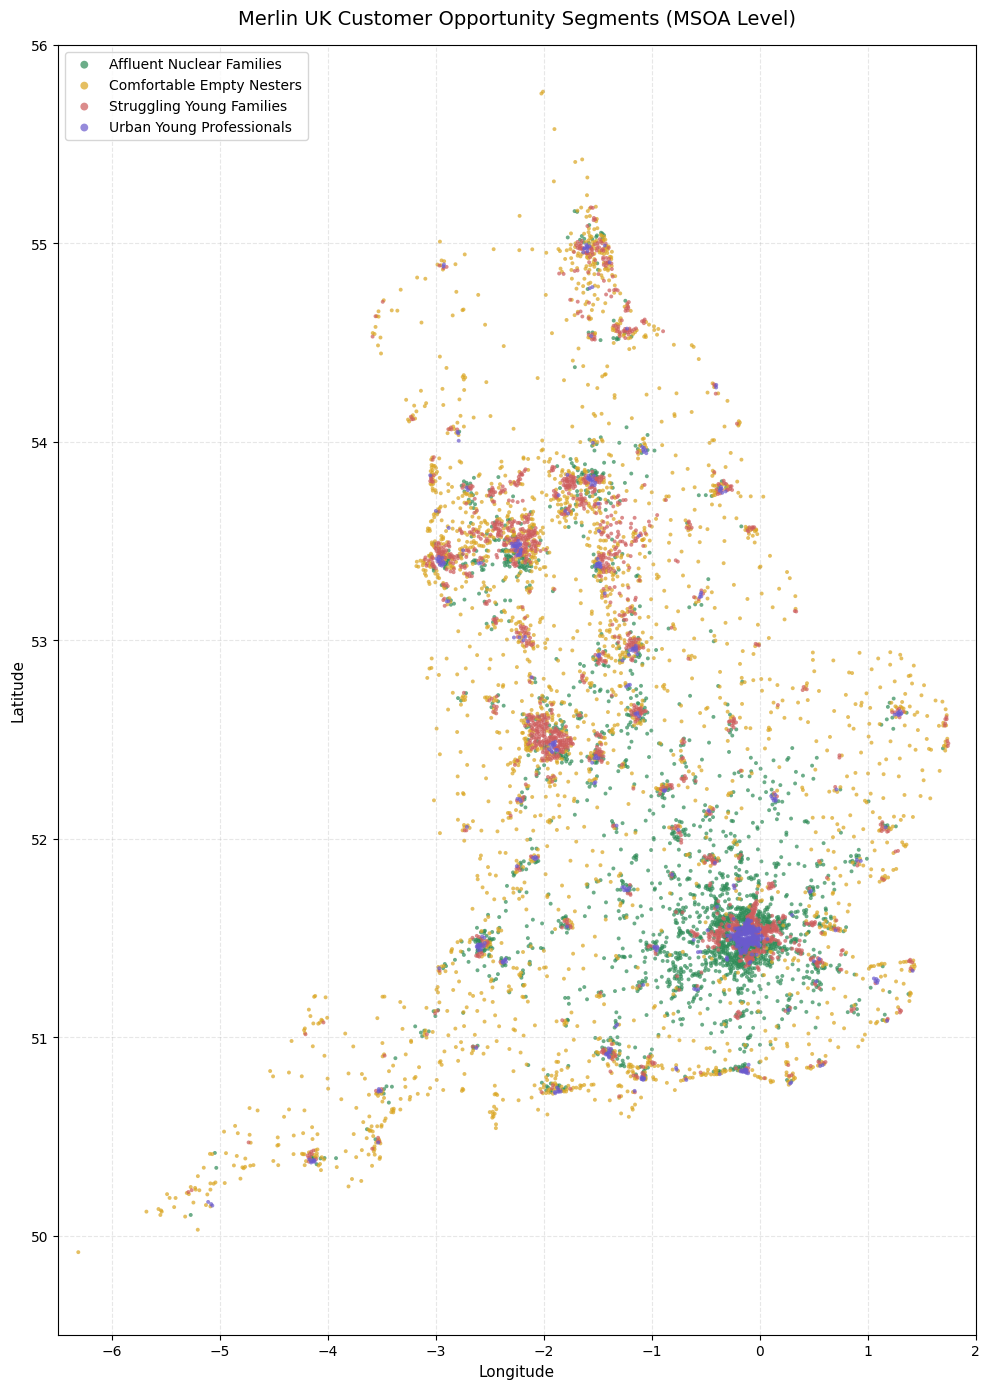

In [312]:
import matplotlib.pyplot as plt

# One row per MSOA with cluster assignment
plot_df = data_df[['geography_code', 'cluster_name', 'latitude_msoa',
'longitude_msoa']].drop_duplicates()

# Colour palette (distinct, colourblind-friendly)
cluster_colours = {
    'Affluent Nuclear Families': '#2E8B57',      # sea green — money/family
    'Comfortable Empty Nesters': '#DAA520',      # goldenrod — retirees
    'Struggling Young Families': '#CD5C5C',      # indian red — price-sensitive      
    'Urban Young Professionals': '#6A5ACD',      # slate blue — city/young
}

fig, ax = plt.subplots(figsize=(10, 14))

for cluster_name, colour in cluster_colours.items():
    subset = plot_df[plot_df['cluster_name'] == cluster_name]
    ax.scatter(
        subset['longitude_msoa'],
        subset['latitude_msoa'],
        c=colour,
        label=cluster_name,
        s=8,
        alpha=0.7,
        edgecolors='none',
    )

ax.set_xlim(-6.5, 2.0)
ax.set_ylim(49.5, 56.0)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Merlin UK Customer Opportunity Segments (MSOA Level)', fontsize=14,    
pad=15)
ax.legend(loc='upper left', frameon=True, markerscale=2)

# Add a subtle grid
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('cluster_map_static.png', dpi=300, bbox_inches='tight')
plt.show()

In [313]:
data_df

,geography_code,longitude_msoa,latitude_msoa,geography,age_total,age_4_and_under,age_5_to_9,age_10_to_14,age_15_to_19,age_20_to_24,age_25_to_29,age_30_to_34,age_35_to_39,age_40_to_44,age_45_to_49,age_50_to_54,age_55_to_59,age_60_to_64,age_65_to_69,age_70_to_74,age_75_to_79,age_80_to_84,age_85_and_over,net_annual_disposable_income,income_score_rate_weighted_avg,index_of_multiple_deprivation_imd_score_weighted_avg,income_deprivation_affecting_children_index_idaci_score_rate_weighted_avg,income_deprivation_affecting_older_people_idaopi_score_rate_weighted_avg,barriers_to_housing_and_services_score_weighted_avg,does_not_apply,one_person_aged_66_plus,one_person_other,other_household_other_family,other_household_students_66_plus,other_household_dep_children,single_family_aged_66_plus,cohabiting_couple_non_dep_children,cohabiting_couple_no_children,cohabiting_couple_dep_children,lone_parent_non_dep_children,lone_parent_dep_children,married_couple_non_dep_children,married_couple_dep_children,married_couple_no_children,total_households,prop_children_0_14,prop_teenagers_15_19,prop_young_adults_20_34,prop_family_core_25_49,prop_older_adults_65_plus,prop_households_with_dep_children,prop_couples_with_dep_children,prop_lone_parent,prop_one_person_households,prop_retired_households,cluster,cluster_name,attraction_name,latitude_attraction,longitude_attraction,distance_km,opportunity_score,opportunity_score_100,activation_recommendation
0,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,SEA LIFE Weymouth Adventure Park,50.625196,-2.445265,191.956568,0.035434,5.9,Low priority / avoid
1,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,SEA LIFE Brighton,50.819598,-0.135751,77.839440,0.150294,16.4,City date experience; evening events
2,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,Chessington World Of Adventures Resort,51.348525,-0.318943,24.527914,0.149868,16.1,Urban awareness; commuter digital out-of-home
3,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,Thorpe Park,51.405106,-0.512665,31.611297,0.524858,69.0,Thrill-seeker day-trip; influencer partnership
4,E02000001,-0.094693,51.519151,City of London 001,8580,213,159,174,216,965,1213,1002,726,547,544,640,517,458,393,318,210,164,121,64385,0.066016,10.209772,0.201790,0.116282,14.265095,0.0,494.0,2012.0,96.0,396.0,31.0,201.0,10.0,598.0,57.0,85.0,90.0,70.0,253.0,523.0,4916.0,0.063636,0.025175,0.370629,0.469930,0.140559,0.087673,0.063059,0.035598,0.509764,0.221928,3,Urban Young Professionals,LEGOLAND® Windsor Resort,51.463773,-0.649911,38.929626,0.097328,9.9,Low priority / avoid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [322]:
import plotly.express as px

plot_df = data_df[['geography_code', 'geography', 'cluster_name', 'latitude_msoa', 'longitude_msoa']].drop_duplicates()

fig = px.scatter(
    plot_df,
    x='longitude_msoa',
    y='latitude_msoa',
    color='cluster_name',
    color_discrete_map=cluster_colours,
    hover_data={'geography_code': True, 'geography': True, 'cluster_name': True, 'latitude_msoa': False,     
'longitude_msoa': False},
    opacity=0.7,
    title='Merlin UK Customer Opportunity Segments',
    width=900,
    height=1100,
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(
    xaxis=dict(range=[-6.5, 2.0], title='Longitude'),
    yaxis=dict(range=[49.5, 56.0], title='Latitude', scaleanchor='x'),
    legend=dict(title='Segment', yanchor='top', y=0.99, xanchor='left', x=0.01),     
)

fig.write_html('cluster_map_interactive.html')